# 求解Navier-Stokes方程

## 1. 算法背景

非线性微分方程组在自然科学和工程领域中扮演着关键的角色，用于描述一系列复杂的现象和问题，包括Navier-Stokes方程、等离子体流体动力学和流行病学等。这些方程组的求解对于理解自然现象、优化系统性能和解决实际问题至关重要。变分量子算法是一类利用经典优化器来训练含参量子线路的算法，它们可以用来求解哈密顿量的本征值、组合优化问题、机器学习问题等。变分量子算法的基本思想是，通过调整量子线路中的参数，使得某个损失函数达到最小值，从而得到问题的最优解或者近似解。变分量子算法的优势在于，它们只需要较少的量子资源，适合在带噪声的中型量子计算机上运行。这里我们基于DeepQuantum定制化开发了一个变分量子算法来求解非线性常微分方程组，并以Navier-Stokes方程的收敛-发散喷嘴问题作为一个具体例子进行了演示。

### Navier-Stokes方程的基本形式

Navier-Stokes方程可以写作以下形式：

$$
\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla) \mathbf{u} = -\frac{1}{\rho} \nabla p + \nu \nabla^2 \mathbf{u} + \mathbf{f}
$$

其中：
- $\mathbf{u}$ 是流体的速度向量，依赖于时间 $t$ 和空间位置。
- $\rho$ 是流体的密度。
- $p$ 是流体的压强。
- $\nu$ 是动力粘性系数，它描述了流体内部的粘滞性。
- $\mathbf{f}$ 是作用在流体上的体积力（如重力）。

### 方程解释

- **时间导数** $\frac{\partial \mathbf{u}}{\partial t}$ 表示流体速度随时间的变化。
- **对流项** $(\mathbf{u} \cdot \nabla) \mathbf{u}$ 表示流体因其速度场的非均匀分布而导致的自身运动的影响。
- **压力梯度** $-\frac{1}{\rho} \nabla p$ 说明压力的变化驱动流体运动。
- **粘性项** $\nu \nabla^2 \mathbf{u}$ 描述了流体内部的摩擦力对流体运动的影响。
- **体积力** $\mathbf{f}$ 是外部力如重力或电磁力的作用。

## 2. 收敛-发散喷嘴问题



<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_10_0001.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

这个问题即要求一维流体经过上图所示的结构，然后计算流体流动的密度、温度和速度分布，具体的方程组如下所示 [1]：

$$
\begin{align*}
\frac{\partial \rho}{\partial t} &= -\rho \frac{\partial V}{\partial x} - \rho V \frac{\partial (\ln A)}{\partial x} - V \frac{\partial \rho}{\partial x}, \\
\frac{\partial T}{\partial t} &= -V \frac{\partial T}{\partial x} - (\gamma - 1)T \left( \frac{\partial V}{\partial x} + V \frac{\partial (\ln A)}{\partial x} \right), \\
\frac{\partial V}{\partial t} &= -V \frac{\partial V}{\partial x} - \frac{1}{\gamma} \left( \frac{\partial T}{\partial x} + \frac{T}{\rho} \frac{\partial \rho}{\partial x} \right),
\end{align*}
$$

为了进一步简化问题，我们考虑稳态情况的解，即有：

$$
\begin{align*}
\frac{dp}{dx} &= \frac{\rho V^2}{T - V^2} d_x(\ln A), \\
\frac{dT}{dx} &= \frac{TV^2(\gamma - 1)}{T - V^2} d_x(\ln A), \\
\frac{dV}{dx} &= -\frac{TV}{T - V^2} d_x(\ln A).
\end{align*}
$$

这里的A(x)描述了喷嘴的形状。

## 3. 算法原理

将变量x通过角度编码加入参数化量子线路（parameterized quantum circuit，PQC）后，可以通过测量得到指定可观测量的期望值。这就实现了一个可变分的函数映射。并且当PQC对变量x进行角度编码时，可以通过参数位移法得到变量x的精确梯度，于是利用这种可微量子线路（differentiable quantum circuit，DQC），把函数项与导数项联系起来后，就可以自然地求解常微分方程。总体流程图包含确定输入、初始化量子线路、优化量子线路以及终止条件。

在输入方面，主要是确定要求解的微分方程（组）和边界条件。在初始化量子线路方面，可以选择不同的变分拟设（ansatz），选择不同的特征映射函数，选择不同的代价函数、损失函数以及选择不同的处理边界条件的方法。在优化量子线路方面，通过采用混合量子-经典的工作流，对DQC进行训练，以满足微分方程和指定的边界条件。最后当损失函数收敛到一定阈值或者训练轮数到达指定值时，结束训练。

具体到这个案例，我们利用经典的非线性激活函数设计了一个量子特征映射，使得对于输入而言相当于引入了Chebyshev多项式，直观理解就是量子比特越多，拟合函数所使用的Chebyshev多项式的阶数越高。该映射提供了一个强大的拟合多项式的基函数集合，并具有丰富的表达能力。对于边界条件的处理，通过floating boundary handling，即对期望值加一个常数来作为预测值，在每次迭代中都调整这个常数使得预测值满足边界条件，可以完美处理单边的边界条件。更多细节我们将结合代码进行说明。

总的来说，变分量子算法对于非线性特征映射、线路结构、测量期望值等选择是多种多样的，同时优化过程中，需要根据具体问题的特点选择合适的优化策略以及相关超参数，大家可以自行进行相关探索。


## 4. 代码实现

DQC类根据指定的量子比特数和层数来进行初始化，并且可以指定量子特征映射的形式，比如内置了"chebyshev"和"chebyshev_tower"两种，我们也可以将自定义的量子特征映射加入"nonlinear"。

"circuit"函数用于构建量子线路的结构，这里默认第一层Ry作为数据编码层（由encode参数指定），然后由一层Rz一层Rx一层Rz再加两层交错的CNOT作为变分层并且可以多次重复。用户也可以在这里构建自定义的量子线路。如果没有指定可观测量的个数，则默认对每个量子比特做z测量。

"get_observable"函数根据量子线路的比特数以及所需的可观测量的个数，返回一个包含一系列可观测量的列表。

"forward"函数实现前向计算过程，经典数据经过量子特征映射以及量子线路的演化，所得到的可观测量期望值之和即作为输出。

In [1]:
import deepquantum as dq
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm

# 变分量子算法
class DQC(nn.Module):
    def __init__(self, nqubit, nlayer, nob=None, feat_map='chebt'):
        super().__init__()
        # 初始化量子位个数、层数、观测数和特征映射
        self.nqubit = nqubit
        self.nlayer = nlayer
        self.nob = nob
        self.feat_map = feat_map
        # 构建量子线路
        self.cir = self.circuit(nqubit, nlayer, nob)

    # 定义chebyshev特征映射（第一类）
    def chebyshev(self, x):
        phi = []
        for _ in range(self.nqubit):
            # 对每个量子位应用切比雪夫变换
            phi.append(2 * torch.arccos(x))
        return torch.cat(phi, dim=-1)

    # 定义chebyshev_tower特征映射
    def chebyshev_tower(self, x):
        phi = []
        for i in range(self.nqubit):
            # 变化频率随量子位位置增加
            phi.append(2 * (i + 1) * torch.arccos(x))
        return torch.cat(phi, dim=-1)

    # 根据选择的特征映射类型应用非线性变换
    def nonlinear(self, x):
        if self.feat_map == 'cheb':
            return self.chebyshev(x)
        if self.feat_map == 'chebt':
            return self.chebyshev_tower(x)

    # 构建量子线路
    def circuit(self, nqubit, nlayer, nob):
        # 初始化量子线路
        cir = dq.QubitCircuit(nqubit)
        # 添加编码层
        cir.rylayer(encode=True)
        for _ in range(nlayer):
            # 对于每层添加旋转和受控非门
            cir.rzlayer()
            cir.rylayer()
            cir.rzlayer()
            wires = list(range(nqubit))
            # 添加交错的受控非门
            for i in wires[1::2]:
                cir.cnot(i - 1, i)
            for i in wires[2::2]:
                cir.cnot(i - 1, i)
        # 根据是否指定观测设备添加观测
        if nob is None:
            for i in range(nqubit):
                cir.observable(i)
        else:
            obs = DQC.get_observable(nqubit, nob)
            for ob in obs:
                cir.observable(wires=ob['wires'], basis=ob['basis'])
        return cir
    
    @staticmethod
    def get_observable(nqubit, nob):
        """获取所有可能的观测量。
        """
        assert nob < 4 ** nqubit  # 确保提供的观测量数量不超过最大可能数量
        ob_lst = []
        bit_ob = {'00': 'i', '01': 'x', '10': 'y', '11': 'z'}  # 定义比特到观测基的映射
        # 每个观测量由一个数字表示
        num = 1
        while num <= nob:
            wires = []  # 要作用的量子比特线
            basis = ''  # 对应的Pauli基
            bits = format(num, f'0{2 * nqubit}b')  # 将数字转换成二进制格式，长度为2*nqubit
            for i in range(nqubit):
                pauli = bit_ob[bits[2*i:2*i+2]]  # 获取对应的Pauli操作
                if pauli != 'i':  # 如果操作不是恒等操作（'i'），则记录下来
                    wires.append(i)
                    basis += pauli
            ob = {'wires': wires, 'basis': basis}  # 创建一个观测量的字典
            ob_lst.append(ob)  # 添加到列表中
            num += 1
        return ob_lst

    def forward(self, x):
        """前向传播函数，用于神经网络模型中。
        """
        x = torch.arctan(x)  # 对输入数据应用反正切函数作为预处理
        x = self.nonlinear(x)  # 应用非线性函数处理数据
        self.cir(x)  # 使用预设的量子电路对数据进行处理
        exp = self.cir.expectation()  # 获取量子电路的期望值
        out = exp.sum(dim=-1, keepdim=True)  # 对期望值进行求和，以生成最终的输出张量
        return out

NavierStokes类实现对处理问题方式的建模，用户可以指定DQC的信息，以及Navier-Stokes方程的收敛-发散喷嘴问题中的单边边界条件，包括对边界条件的处理方法。这里的'float'即代表上面介绍的floating boundary的处理方式。"forward"函数实现具体的函数拟合，给定坐标x，返回密度、温度和速度。

"loss_ns_stationary_conv_div_nozzle" 函数实现根据要求解的常微分方程组来构建损失函数。具体而言，对于目前这个案例，所采用的喷嘴的形状为：

$$
A(x) = 1 + 4.95(2x - 1)^2, \quad 0 \leq x \leq 1,
$$

所要求解的常微分方程组为：

$$
\begin{align*}
\frac{dp}{dx} &= \frac{\rho V^2}{T - V^2} d_x(\ln A), \\
\frac{dT}{dx} &= \frac{TV^2(\gamma - 1)}{T - V^2} d_x(\ln A), \\
\frac{dV}{dx} &= -\frac{TV}{T - V^2} d_x(\ln A).
\end{align*}
$$

代码与方程是对应的.

"loss_reg_ns_stationary_conv_div_nozzle"函数实现根据指定的预期目标来返回正则项。

整个训练过程包含了两个阶段的训练。我们需要输入待训练的模型、训练集数据、正则项数据、损失函数和正则项的形式、要使用的优化器、迭代轮数、控制正则项衰减的超参数以及运行设备。训练完返回训练好的模型以及训练过程中记录的损失函数情况。

In [2]:
class NavierStokes(nn.Module):
    def __init__(self, nqubit, nlayer, x0, rho0, tem0, vel0, feat_map='cheb', bound='float'):
        super().__init__()
        self.nqubit = nqubit
        self.nlayer = nlayer
        self.feat_map = feat_map
        self.bound = bound
        self.rho = DQC(nqubit, nlayer, feat_map=feat_map)
        self.tem = DQC(nqubit, nlayer, feat_map=feat_map)
        self.vel = DQC(nqubit, nlayer, feat_map=feat_map)
        x0 = x0.reshape(-1, 1)
        self.register_buffer('x0', x0)
        self.rho0 = rho0
        self.tem0 = tem0
        self.vel0 = vel0

    def forward(self, x):
        rho = self.rho(x)
        tem = self.tem(x)
        vel = self.vel(x)
        if self.bound == 'float':
            rho += self.rho0 - self.rho(self.x0).detach().clone()
            tem += self.tem0 - self.tem(self.x0).detach().clone()
            vel += self.vel0 - self.vel(self.x0).detach().clone()
        return rho, tem, vel


def loss_ns_stationary_conv_div_nozzle(model, x, criterion):
    gamma = 1.4
    d_ln_a = (19.8 * (2 * x - 1)) / (1 + 4.95 * (2 * x - 1) ** 2)
    rho, t, v = model(x)
    v2 = v ** 2
    drho = torch.autograd.grad(rho, x, grad_outputs=torch.ones_like(rho), create_graph=True)[0]
    dt = torch.autograd.grad(t, x, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dv = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    labels = torch.zeros_like(x, device=x.device)
    loss_rho = criterion(drho - rho * v2 * d_ln_a / (t - v2), labels)
    loss_tem = criterion(dt - t * v2 * (gamma - 1) *  d_ln_a / (t - v2), labels)
    loss_vel = criterion(dv + t * v * d_ln_a / (t - v2), labels)
    return loss_rho + loss_tem + loss_vel

def loss_reg_ns_stationary_conv_div_nozzle(model, x_reg, rho_reg, tem_reg, vel_reg, criterion):
    rho, tem, vel = model(x_reg)
    loss_rho = criterion(rho, rho_reg)
    loss_tem = criterion(tem, tem_reg)
    loss_vel = criterion(vel, vel_reg)
    return loss_rho + loss_tem + loss_vel


def train(model, x_train1, x_train2, x_reg, criterion, criterion_reg, optimizer1, optimizer2,
          niter1, niter2, delta, device):
    model = model.to(device)
    x_train1 = x_train1.to(device)
    x_train2 = x_train2.to(device)
    x_reg = x_reg.to(device)

    l_stage1 = []
    l_stage2_full = []
    l_stage2_diff = []
    for i in tqdm(range(niter1)):
        optimizer1.zero_grad()
        loss = loss_ns_stationary_conv_div_nozzle(model, x_train1, criterion)
        loss.backward()
        optimizer1.step()
        l_stage1.append(loss.item())

    rho_reg, tem_reg, vel_reg = model(x_reg)
    rho_reg = rho_reg.detach().clone()
    tem_reg = tem_reg.detach().clone()
    vel_reg = vel_reg.detach().clone()
    
    for i in tqdm(range(niter2)):
        optimizer2.zero_grad()
        loss_diff = loss_ns_stationary_conv_div_nozzle(model, x_train2, criterion)
        sche = 1 - np.tanh((i + 1) / (delta * niter2))
        loss = loss_diff + sche * loss_reg_ns_stationary_conv_div_nozzle(model, x_reg, rho_reg, tem_reg, vel_reg, criterion_reg)
        loss.backward()
        optimizer2.step()
        l_stage2_full.append(loss.item())
        l_stage2_diff.append(loss_diff.item())

    result = {'loss_stage1': l_stage1, 'loss_stage2_full': l_stage2_full, 'loss_stage2_diff': l_stage2_diff}
    return model, result

这里统一列出了与训练过程相关的一些参数。我们还可以修改模型、损失函数和正则项的形式以及优化器的相关信息。比如这里默认使用了6个量子比特和6层线路结构，默认的边界条件为：

$
\rho(x = 0) = 1, \quad T(x = 0) = 1, \quad V(x = 0) = 0.1,
$

确定好所有参数后运行

100%|██████████| 600/600 [03:55<00:00,  2.55it/s]


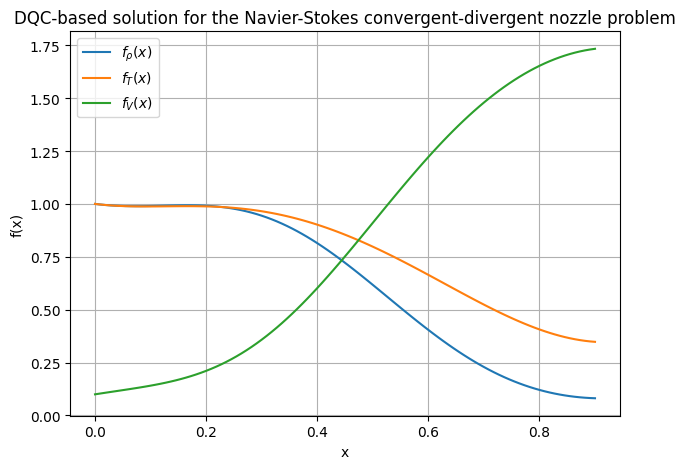

In [3]:
x1 = 0          # 第一段空间的起点
x2 = 0.4        # 第一段空间的终点
x3 = 0.6        # 第二段空间的起点
x4 = 0.9        # 第二段空间的终点
nstep1 = 20     # 第一段空间的点数
nstep_reg1 = 20 # 第一段空间的正则项所用的点数
nstep2 = 20     # 第二段空间的点数
nstep_reg2 = 5  # 第二段空间的正则项所用的点数
niter1 = 200    # 一阶段训练迭代次数
niter2 = 600    # 二阶段训练迭代次数
delta = 1 / 8   # 控制正则项衰减的超参数
device = 'cpu'


x_train1 = torch.linspace(x1, x2, nstep1, requires_grad=True).reshape(-1, 1)
x_train2 = torch.linspace(x3, x4, nstep2, requires_grad=True).reshape(-1, 1)
x_reg1 = torch.linspace(x1, x2, nstep_reg1).reshape(-1, 1)
x_reg2 = torch.linspace(x3, x4, nstep_reg2).reshape(-1, 1)
x_train = torch.cat([x_train1, x_train2], dim=0)
x_reg = torch.cat([x_reg1, x_reg2], dim=0)
x_test = torch.linspace(x1, x4, 100).reshape(-1, 1)
model = NavierStokes(6, 6, x_train[0, 0], 1, 1, 0.1)
criterion = nn.MSELoss()
criterion_reg = nn.MSELoss(reduction='sum')
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
optimizer2 = torch.optim.Adam(model.parameters(), lr=0.005, betas=(0.9, 0.999))
model, rst = train(model, x_train1, x_train, x_reg, criterion, criterion_reg, optimizer1, optimizer2, niter1, niter2, delta, device)


l_stage1 = rst['loss_stage1']
l_stage2_full = rst['loss_stage2_full']
l_stage2_diff = rst['loss_stage2_diff']
plt.plot(l_stage1)
plt.xlabel('n')
plt.ylabel('loss')
plt.yscale('log')
plt.grid()
plt.tight_layout()
plt.clf()

plt.plot(l_stage2_diff, label='$L_{D}$')
plt.plot(l_stage2_full, label='$L_{F}$')
plt.xlabel('n')
plt.ylabel('loss')
plt.yscale('log')
plt.grid()
plt.legend()
plt.tight_layout()
plt.clf()

rho, tem, vel = model(x_test)
plt.plot(x_test.numpy(), rho.detach().numpy(), label=r'$f_{\rho}(x)$')
plt.plot(x_test.numpy(), tem.detach().numpy(), label=r'$f_{T}(x)$')
plt.plot(x_test.numpy(), vel.detach().numpy(), label=r'$f_{V}(x)$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('DQC-based solution for the Navier-Stokes convergent-divergent nozzle problem')
plt.grid()
plt.legend()
plt.tight_layout()

## 参考文献

[1] Kyriienko, O., Paine, A. E., & Elfving, V. E. (2021). Solving nonlinear differential equations with differentiable quantum circuits. Physical Review A, 103(5), 052416.